# Analysis of mutations

In [3]:
import pandas as pd
import os, sys
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from itertools import combinations

# from scipy.stats import linregress
# from matplotlib_venn import venn2
# from tqdm import tqdm
# tqdm.pandas()

In [4]:
# maf_df = pd.read_table(maf_file)
all_omegas = pd.read_table("all_omegas.tsv")
all_omegas_gloc = pd.read_table("all_omegas_global_loc.tsv")


In [5]:
per_sample_o = all_omegas[~(all_omegas["gene"].str.contains("--"))
                            & (all_omegas["sample"].str.startswith("P19"))
                            & (all_omegas["impact"].isin(["missense", "truncating"]))
                            ]

In [6]:
per_sample_ogloc = all_omegas_gloc[~(all_omegas_gloc["gene"].str.contains("--"))
                                    & (all_omegas_gloc["sample"].str.startswith("P19"))
                                    & (all_omegas_gloc["impact"].isin(["missense", "truncating"]))
                                    ]

In [7]:
per_sample_o.shape, per_sample_ogloc.shape

((1531, 8), (2067, 8))

In [8]:
per_sample_o.groupby("impact").size(), per_sample_ogloc.groupby("impact").size()

(impact
 missense      831
 truncating    700
 dtype: int64,
 impact
 missense      1182
 truncating     885
 dtype: int64)

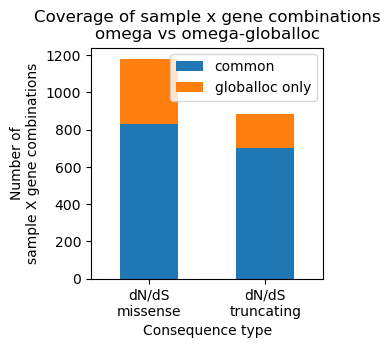

In [9]:
omega_counts = per_sample_o.groupby("impact").size()
ogloc_counts = per_sample_ogloc.groupby("impact").size() - omega_counts

counts = pd.DataFrame({
    'Category': ['dN/dS\nmissense', 'dN/dS\ntruncating'],
    'common': [ omega_counts["missense"],  omega_counts["truncating"]],
    'globalloc only': [ ogloc_counts["missense"],  ogloc_counts["truncating"]]
})


plt.figure(figsize=(3, 3))
counts.set_index('Category').plot(kind='bar', stacked=True, ax=plt.gca())
plt.xticks(rotation=0)
plt.title('Coverage of sample x gene combinations\nomega vs omega-globalloc')
plt.ylabel('Number of\nsample X gene combinations')
plt.xlabel("Consequence type")
plt.savefig("dnds_coverage_comparison.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
merged_omegas = per_sample_o.merge(per_sample_ogloc, on=["gene", "sample", "impact", "mutations"], suffixes=("_o", "_ogloc"))
merged_omegas

,gene,sample,impact,mutations,dnds_o,pvalue_o,lower_o,upper_o,dnds_ogloc,pvalue_ogloc,lower_ogloc,upper_ogloc
0,FGFR3,P19_0038_BDO_01,missense,3,0.684375,4.847888e-01,0.170032,1.783008,1.024901,0.966406,0.254805,2.670409
1,RBM10,P19_0038_BDO_01,missense,13,1.674988,8.967042e-02,0.916475,2.782776,1.038306,0.894183,0.567836,1.724341
2,RBM10,P19_0038_BDO_01,truncating,4,3.632910,3.416437e-02,1.121816,8.536475,2.250439,0.154795,0.694822,5.289380
3,CDKN1A,P19_0038_BDO_01,missense,2,0.841797,8.036910e-01,0.139968,2.614258,0.996881,0.995877,0.166128,3.091608
4,CDKN1A,P19_0038_BDO_01,truncating,1,3.440625,3.055273e-01,0.195937,15.299146,4.071777,0.255065,0.232128,18.094604
...,...,...,...,...,...,...,...,...,...,...,...,...
1526,KDM6A,P19_0002_BDO_01,truncating,32,18.096875,0.000000e+00,12.303975,25.676221,27.718750,0.000000,18.850901,39.338623
1527,CREBBP,P19_0002_BDO_01,missense,41,3.207813,0.000000e+00,2.301401,4.344287,2.318750,0.000004,1.663777,3.140283
1528,CREBBP,P19_0002_BDO_01,truncating,12,8.040625,1.192093e-07,4.250782,13.756567,5.812497,0.000003,3.072744,9.944577
1529,ALL_GENES,P19_0002_BDO_01,missense,403,2.235132,0.000000e+00,1.971115,2.531763,2.229688,0.000000,1.966316,2.525098


In [11]:
merged_omegas["dnds_o"].min()

np.float64(0.1056579589843742)

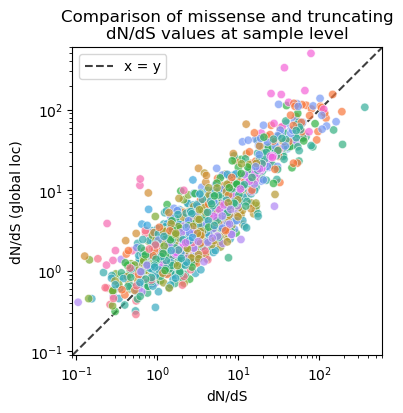

In [12]:
plt.figure(figsize=(4, 4))
sns.scatterplot(data=merged_omegas,
                x="dnds_o",
                y="dnds_ogloc",
                alpha = 0.7,
                hue="gene",
                legend = False
                )
plt.xlim(0.09, 600)
plt.ylim(0.09, 600)

# add x == y line
lims = [0.09, 600]
plt.plot(lims, lims, 'k--', label = "x = y", alpha=0.75, zorder=0)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("dN/dS")
plt.ylabel("dN/dS (global loc)")
plt.title("Comparison of missense and truncating\ndN/dS values at sample level")
plt.legend()
plt.savefig("dnds_comparison.pdf", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 400x400 with 0 Axes>

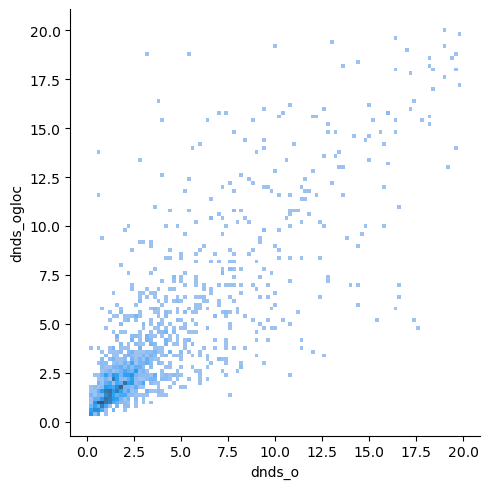

In [15]:
plt.figure(figsize=(4, 4))
upper_lim = 20
sns.displot(data = merged_omegas[(merged_omegas["dnds_o"] < upper_lim)
                                 & (merged_omegas["dnds_ogloc"] < upper_lim)
                                 ],
                x="dnds_o",
                y="dnds_ogloc",
                binwidth=(.2, .2),
                )
# # add x == y line
# lims = [0.09, 600]
# plt.plot(lims, lims, 'k--', label = "x = y", alpha=0.75, zorder=0)

# plt.xscale("log")
# plt.yscale("log")
# plt.xlabel("dN/dS")
# plt.ylabel("dN/dS (global loc)")
# plt.title("Comparison of missense and truncating\ndN/dS values at sample level")
# plt.legend()
# plt.savefig("dnds_comparison.pdf", dpi=300, bbox_inches="tight")
plt.show()